Практическое занятие 11: Задача регрессии (прогнозирование стоимости недвижимости)

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_log_error, r2_score, mean_absolute_error
from sklearn.pipeline import make_pipeline
import category_encoders as ce
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

Шаг 1

In [2]:
print("Шаг 1: Загрузка данных и библиотек")
df = pd.read_csv('all_v2.csv', parse_dates=['date'])  # считываем, date как datetime
# Фильтр по региону 2661 (Санкт-Петербург и область)
df = df[df['region'] == 2661].copy()
print(f"Размер после фильтрации по региону: {df.shape}")

Шаг 1: Загрузка данных и библиотек
Размер после фильтрации по региону: (461820, 13)


Шаг 2 

In [3]:
print("\nШаг 2: Оставляем только типовые объекты")
print(f"До фильтрации: {df.shape[0]}")
df = df[(df['area'] >= 20) & (df['area'] <= 200)]
df = df[(df['kitchen_area'] >= 6) & (df['kitchen_area'] <= 30)]
df = df[(df['price'] >= 1_500_000) & (df['price'] <= 50_000_000)]
print(f"После фильтрации: {df.shape[0]}")


Шаг 2: Оставляем только типовые объекты
До фильтрации: 461820
После фильтрации: 410663


Шаг 3

In [4]:
print("\nШаг 3: Замена -1 и -2 в комнатах на 0")
df['rooms'] = df['rooms'].replace([-1, -2], 0)


Шаг 3: Замена -1 и -2 в комнатах на 0


Шаг 4

In [5]:
print("\nШаг 4: Добавление новых признаков")
# Этаж квартиры / этажность
df['floor_ratio'] = df['level'] / df['levels'].replace(0, np.nan)  # избегаем деления на 0
df['floor_ratio'].fillna(0, inplace=True)
# Первый этаж
df['is_first'] = (df['level'] == 1).astype(int)
# Последний этаж
df['is_last'] = (df['level'] == df['levels']).astype(int)
# ratio = kitchen_area / area, если комнат 0, то ratio = area
df['ratio'] = df['kitchen_area'] / df['area']
df.loc[df['rooms'] == 0, 'ratio'] = df.loc[df['rooms'] == 0, 'area']


Шаг 4: Добавление новых признаков


Шаг 5 

In [6]:
print("\nШаг 5: Добавление признака давность объявления")
# В качестве даты отсчета используем максимальную дату в наборе данных
ref_date = df['date'].max()
df['days_since_listed'] = (ref_date - df['date']).dt.days


Шаг 5: Добавление признака давность объявления


Шаг 6

In [7]:
print("\nШаг 6: Матрица корреляции (только числовые + цена)")
numeric_cols = ['price', 'area', 'kitchen_area', 'rooms', 'level', 'levels',
                'floor_ratio', 'is_first', 'is_last', 'ratio', 'days_since_listed',
                'geo_lat', 'geo_lon']
corr_matrix = df[numeric_cols].corr()
print("Корреляция с ценой:")
print(corr_matrix['price'].sort_values(ascending=False))


Шаг 6: Матрица корреляции (только числовые + цена)
Корреляция с ценой:
price                1.000000
area                 0.780188
rooms                0.524654
kitchen_area         0.490240
floor_ratio          0.073884
geo_lat              0.059786
is_last              0.037881
ratio               -0.051590
is_first            -0.060652
geo_lon             -0.069051
level               -0.076799
days_since_listed   -0.146865
levels              -0.177535
Name: price, dtype: float64


Шаг 7

In [8]:
print("\nШаг 7: Кодирование категориальных признаков (Binary Encoder)")
# Определяем категориальные столбцы (не числовые и не целевые)
cat_features = ['region', 'building_type', 'object_type']
# Обрабатываем возможные пропуски
for col in cat_features:
    df[col] = df[col].astype(str)
encoder = ce.BinaryEncoder(cols=cat_features, return_df=True)
encoded_cats = encoder.fit_transform(df[cat_features])
# Удаляем исходные категориальные и объединяем с основным DF
df = pd.concat([df.drop(columns=cat_features), encoded_cats], axis=1)


Шаг 7: Кодирование категориальных признаков (Binary Encoder)


Шаг 8

In [9]:
print("\nШаг 8: Разделение на обучающую и тестовую выборки (80/20, random_state=42)")
# Целевая переменная
y = df['price']
# Признаки: исключаем цену, дату, время (time), а также исходные столбцы, которые закодированы или не нужны
drop_cols = ['price', 'date', 'time'] + cat_features
X = df.drop(columns=drop_cols, errors='ignore')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Обучающая выборка: {X_train.shape}, тестовая: {X_test.shape}")


Шаг 8: Разделение на обучающую и тестовую выборки (80/20, random_state=42)
Обучающая выборка: (328530, 18), тестовая: (82133, 18)


Шаг 9

In [10]:
print("\nШаг 9: Стандартизация и модель Ridge (L2-регуляризация)")
# Стандартизируем числовые признаки (все оставшиеся, кроме закодированных бинарных)
# Бинарные признаки уже в [0,1], их можно не стандартизировать, но для единообразия - тоже можно
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
ridge = Ridge(alpha=1.0)  # alpha по умолчанию
ridge.fit(X_train_scaled, y_train)
y_train_pred_ridge = ridge.predict(X_train_scaled)
y_test_pred_ridge = ridge.predict(X_test_scaled)


Шаг 9: Стандартизация и модель Ridge (L2-регуляризация)


Шаг 10 (стандартизировать необязательно)

In [11]:
print("\nШаг 10: Модель XGBoost (без стандартизации)")
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)  # используем исходные признаки (стандартизация не требуется)
y_train_pred_xgb = xgb_model.predict(X_train)
y_test_pred_xgb = xgb_model.predict(X_test)


Шаг 10: Модель XGBoost (без стандартизации)


Шаг 11

In [13]:
print("\nШаг 11: Расчет метрик RMSLE, R2, MAE")
# Исправленная функция RMSLE с защитой от отрицательных предсказаний
def rmsle(y_true, y_pred):
    y_pred = np.maximum(y_pred, 0)          # обрезаем отрицательные значения
    return np.sqrt(mean_squared_log_error(y_true, y_pred))

print("Результаты Ridge:")
print(f"  Обучающая выборка: RMSLE = {rmsle(y_train, y_train_pred_ridge):.4f}, "
      f"R2 = {r2_score(y_train, y_train_pred_ridge):.4f}, MAE = {mean_absolute_error(y_train, y_train_pred_ridge):.2f}")
print(f"  Тестовая выборка:  RMSLE = {rmsle(y_test, y_test_pred_ridge):.4f}, "
      f"R2 = {r2_score(y_test, y_test_pred_ridge):.4f}, MAE = {mean_absolute_error(y_test, y_test_pred_ridge):.2f}")

print("\nРезультаты XGBoost:")
print(f"  Обучающая выборка: RMSLE = {rmsle(y_train, y_train_pred_xgb):.4f}, "
      f"R2 = {r2_score(y_train, y_train_pred_xgb):.4f}, MAE = {mean_absolute_error(y_train, y_train_pred_xgb):.2f}")
print(f"  Тестовая выборка:  RMSLE = {rmsle(y_test, y_test_pred_xgb):.4f}, "
      f"R2 = {r2_score(y_test, y_test_pred_xgb):.4f}, MAE = {mean_absolute_error(y_test, y_test_pred_xgb):.2f}")


Шаг 11: Расчет метрик RMSLE, R2, MAE
Результаты Ridge:
  Обучающая выборка: RMSLE = 0.5241, R2 = 0.6949, MAE = 1692794.13
  Тестовая выборка:  RMSLE = 0.5241, R2 = 0.6940, MAE = 1708562.10

Результаты XGBoost:
  Обучающая выборка: RMSLE = 0.1817, R2 = 0.8715, MAE = 1000719.52
  Тестовая выборка:  RMSLE = 0.1851, R2 = 0.8650, MAE = 1020200.65


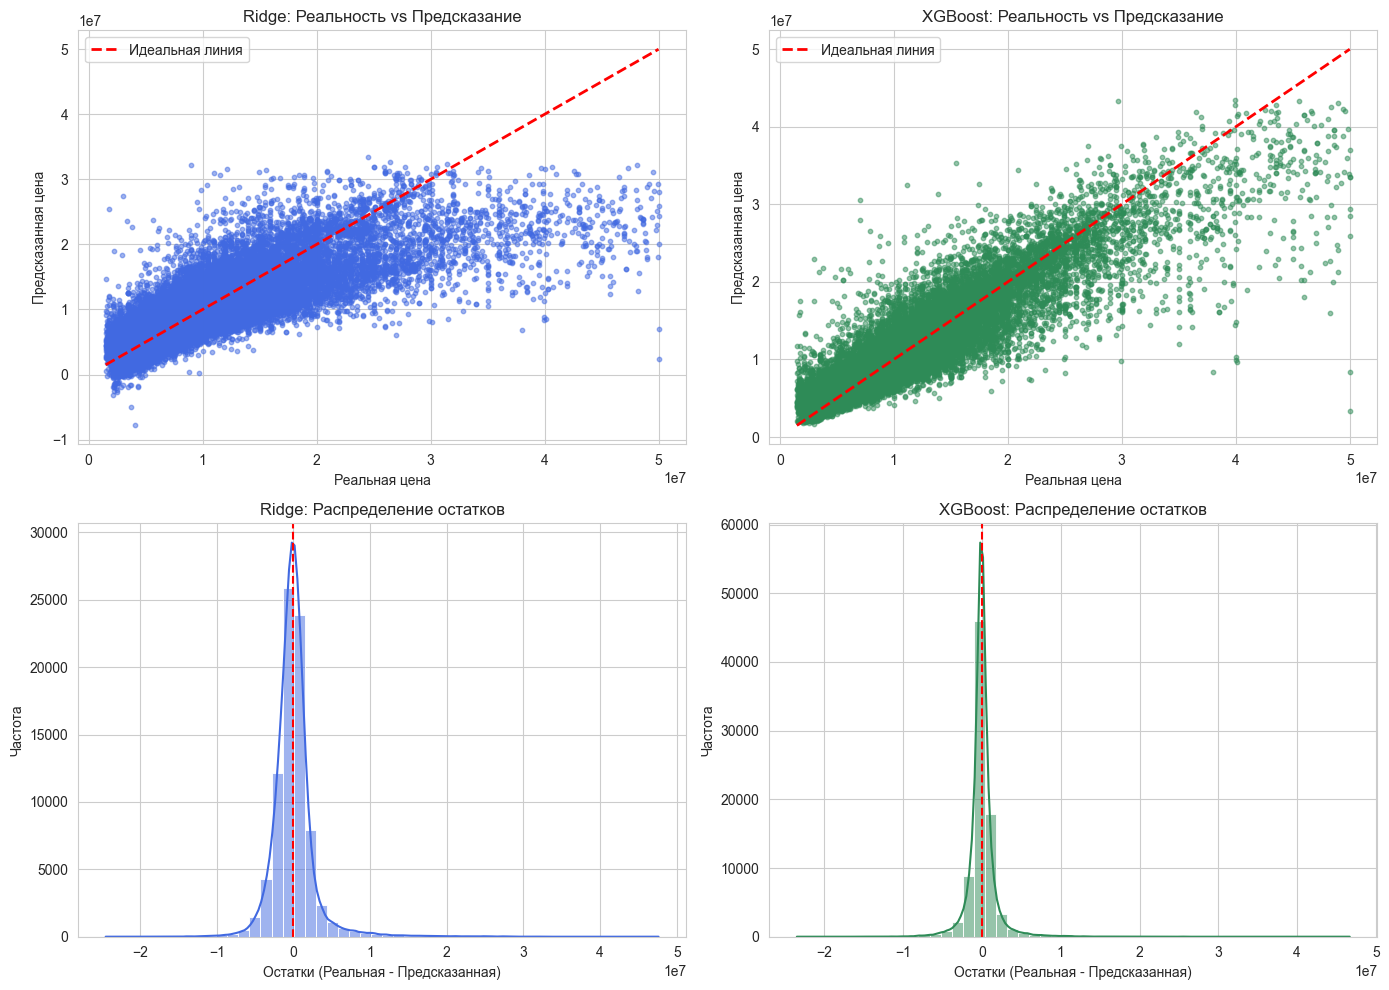


Сравнительная диаграмма метрик (тестовая выборка):


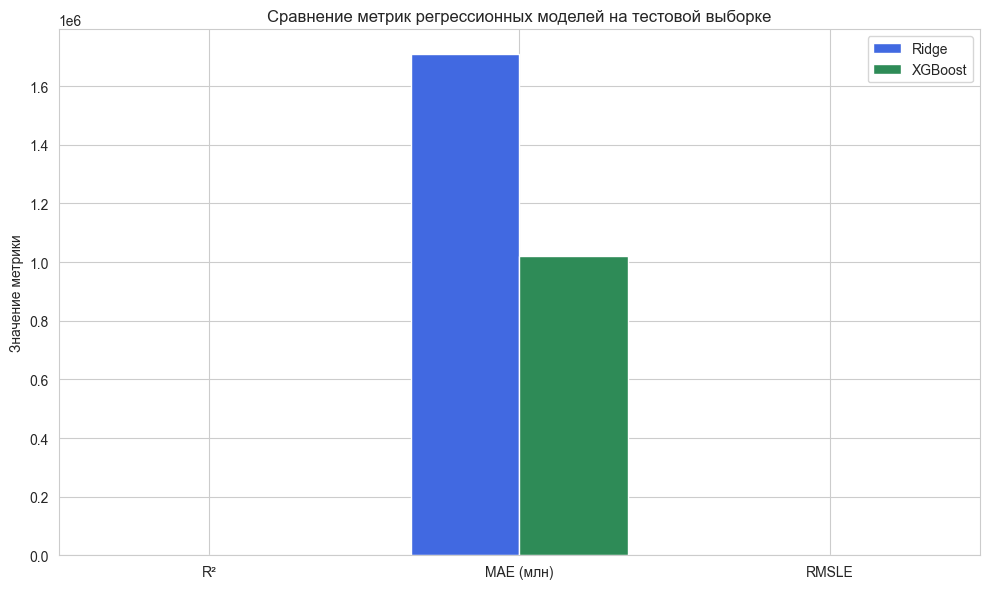

In [16]:
# ====================== ВИЗУАЛИЗАЦИЯ МОДЕЛЕЙ ======================
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка стиля и русского шрифта (если нужен)
plt.rcParams['font.family'] = 'DejaVu Sans'  # или 'Arial' / 'SimHei' для Windows
sns.set_style("whitegrid")

# Функция для рисования графиков
def plot_model_results(y_true, y_pred_ridge, y_pred_xgb, model_names=('Ridge', 'XGBoost')):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Ridge: реальность vs предсказание
    ax1 = axes[0, 0]
    ax1.scatter(y_true, y_pred_ridge, alpha=0.5, s=10, color='royalblue')
    ax1.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2, label='Идеальная линия')
    ax1.set_xlabel('Реальная цена')
    ax1.set_ylabel('Предсказанная цена')
    ax1.set_title(f'{model_names[0]}: Реальность vs Предсказание')
    ax1.legend()
    
    # 2. XGBoost: реальность vs предсказание
    ax2 = axes[0, 1]
    ax2.scatter(y_true, y_pred_xgb, alpha=0.5, s=10, color='seagreen')
    ax2.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2, label='Идеальная линия')
    ax2.set_xlabel('Реальная цена')
    ax2.set_ylabel('Предсказанная цена')
    ax2.set_title(f'{model_names[1]}: Реальность vs Предсказание')
    ax2.legend()
    
    # 3. Гистограмма остатков для Ridge
    ax3 = axes[1, 0]
    residuals_ridge = y_true - y_pred_ridge
    sns.histplot(residuals_ridge, bins=50, kde=True, color='royalblue', ax=ax3)
    ax3.axvline(0, color='red', linestyle='--')
    ax3.set_xlabel('Остатки (Реальная - Предсказанная)')
    ax3.set_ylabel('Частота')
    ax3.set_title(f'{model_names[0]}: Распределение остатков')
    
    # 4. Гистограмма остатков для XGBoost
    ax4 = axes[1, 1]
    residuals_xgb = y_true - y_pred_xgb
    sns.histplot(residuals_xgb, bins=50, kde=True, color='seagreen', ax=ax4)
    ax4.axvline(0, color='red', linestyle='--')
    ax4.set_xlabel('Остатки (Реальная - Предсказанная)')
    ax4.set_ylabel('Частота')
    ax4.set_title(f'{model_names[1]}: Распределение остатков')
    
    plt.tight_layout()
    plt.show()

# Используем тестовую выборку для визуализации (можно и обучающую)
plot_model_results(y_test, y_test_pred_ridge, y_test_pred_xgb)

# Дополнительно: сравнение метрик в виде столбчатой диаграммы
print("\nСравнительная диаграмма метрик (тестовая выборка):")
metrics = {
    'Ridge': [r2_score(y_test, y_test_pred_ridge), 
              mean_absolute_error(y_test, y_test_pred_ridge),
              rmsle(y_test, y_test_pred_ridge)],
    'XGBoost': [r2_score(y_test, y_test_pred_xgb), 
                mean_absolute_error(y_test, y_test_pred_xgb),
                rmsle(y_test, y_test_pred_xgb)]
}

labels = ['R²', 'MAE (млн)', 'RMSLE']
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, metrics['Ridge'], width, label='Ridge', color='royalblue')
ax.bar(x + width/2, metrics['XGBoost'], width, label='XGBoost', color='seagreen')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Значение метрики')
ax.set_title('Сравнение метрик регрессионных моделей на тестовой выборке')
ax.legend()
plt.tight_layout()
plt.show()

Шаг 12

In [17]:
print("\nШаг 12: Сравнение результатов")
print("Модель Ridge показывает линейную зависимость, XGBoost улавливает нелинейности.")
print("Обычно XGBoost даёт лучшие метрики на тесте.")


Шаг 12: Сравнение результатов
Модель Ridge показывает линейную зависимость, XGBoost улавливает нелинейности.
Обычно XGBoost даёт лучшие метрики на тесте.


Шаг 13

In [18]:
print("\nШаг 13: Анализ важности признаков (feature_importances_ из XGBoost)")
importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)
print("Топ-10 важных признаков:")
print(importance.head(10))


Шаг 13: Анализ важности признаков (feature_importances_ из XGBoost)
Топ-10 важных признаков:
              feature  importance
5                area    0.581506
11  days_since_listed    0.066539
3              levels    0.058698
15    building_type_2    0.053187
4               rooms    0.035145
0             geo_lat    0.035025
6        kitchen_area    0.032810
14    building_type_1    0.029039
13    building_type_0    0.026952
1             geo_lon    0.021009


Шаг 14
1. Будущая информация (data leakage): при расчёте использована максимальная дата в датасете. 
   В реальном прогнозе на текущую дату мы не знаем будущих объявлений, поэтому корректнее использовать фиксированную дату (например, сегодняшнюю) или вычитать дату объявления из даты сбора данных для каждой записи индивидуально.
2. Нестационарность: зависимость цены от давности может меняться со временем (сезонность, экономическая ситуация).
3. Пропуски дат: не все объявления могли иметь корректную дату.
4. При решении задачи в отрыве от временнóго контекста модель может научиться неправильным закономерностям (например, старые объявления дешевле, потому что их давно не продали, но это не всегда так)

Шаг 15

In [19]:
print("\nШаг 15: Скоринг нового объекта (вашей квартиры)")
# Пример данных для новой квартиры (замените на реальные значения)
new_flat = pd.DataFrame([{
    'geo_lat': 59.93,
    'geo_lon': 30.31,
    'building_type': '1',        # тип здания (кодируется позже)
    'object_type': '1',          # тип объекта
    'level': 5,                  # этаж
    'levels': 12,                # этажность
    'rooms': 2,
    'area': 65.0,
    'kitchen_area': 12.0,
    'region': '2661'             # регион (СПб)
}])
# Добавляем те же признаки, что и для обучающего набора
new_flat['floor_ratio'] = new_flat['level'] / new_flat['levels']
new_flat['is_first'] = (new_flat['level'] == 1).astype(int)
new_flat['is_last'] = (new_flat['level'] == new_flat['levels']).astype(int)
new_flat['ratio'] = new_flat['kitchen_area'] / new_flat['area']
new_flat.loc[new_flat['rooms'] == 0, 'ratio'] = new_flat.loc[new_flat['rooms'] == 0, 'area']
# Для признака давности объявления – в реальности используем дату сегодня. 
# Поскольку мы не знаем дату, зададим 0 (свежее объявление)
new_flat['days_since_listed'] = 0

# Категориальные признаки кодируем тем же encoder'ом
for col in cat_features:
    new_flat[col] = new_flat[col].astype(str)
new_flat_encoded = encoder.transform(new_flat[cat_features])
new_flat = pd.concat([new_flat.drop(columns=cat_features), new_flat_encoded], axis=1)
# Приводим порядок колонок к X_train (важно!)
new_flat = new_flat.reindex(columns=X_train.columns, fill_value=0)

# Предсказание
pred_price_ridge = ridge.predict(scaler.transform(new_flat))[0]
pred_price_xgb = xgb_model.predict(new_flat)[0]
print(f"Предсказанная цена (Ridge): {pred_price_ridge:,.0f} руб.")
print(f"Предсказанная цена (XGBoost): {pred_price_xgb:,.0f} руб.")

print("\nВсе шаги выполнены успешно!")


Шаг 15: Скоринг нового объекта (вашей квартиры)
Предсказанная цена (Ridge): 9,807,652 руб.
Предсказанная цена (XGBoost): 11,269,551 руб.

Все шаги выполнены успешно!
